## Naive Approach - Distributional Shift with a SMW
In the Naive Approach the distributional Shift comes from mutating random positions in a sequence with a Single Mutant Walker. The sequences are scored by a surrogate model where the best found sequence is added to the trajectroy and used as the next seed sequence for further mutation.


#### SMW and Random Forest on TFBind8

In [1]:
from experiment_runner import ExperimentRunner
import pandas as pd
from assets import compute_metrics

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
runner = ExperimentRunner(keyword='smw_tfbind8')
df = runner.run_and_save()

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



############################################################
Running experiment: smw_tfbind8
Method: smw
Dataset: tfbind8
Runs: 10
Iterations per run: 20
Parallel: True
############################################################

Using 10 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL


Run 1/10 - SMW

Run 9/10 - SMW

Run 3/10 - SMW

Run 4/10 - SMW

Run 8/10 - SMW

Run 2/10 - SMW

Run 5/10 - SMW

Run 7/10 - SMW

Run 6/10 - SMW

Run 10/10 - SMW
✓ Run 1: 1 records (1/10)
✓ Run 9: 3 records (2/10)
✓ Run 3: 3 records (3/10)
✓ Run 8: 1 records (4/10)
✓ Run 4: 1 records (5/10)
✓ Run 6: 1 records (6/10)
✓ Run 10: 3 records (7/10)
✓ Run 7: 6 records (8/10)
✓ Run 5: 5 records (9/10)
✓ Run 2: 9 records (10/10)

Results saved to: results/trajectory_smw_tfbind8.csv
Total records: 33

Summary:
  Runs: 10
  Iterations per run: 2.9
  Avg records per run: 3.3

Oracle scores:
  Min: 0.3262
  Max: 0.8720
  Mean: 0.5371

Hamming distances:
  Min: 0
  Max: 2.0
  Mean: 0.8
Total time: 16.7 seconds (0.3 minutes)


For evaluation following metrics are computed:
- Mean max oracle score (± std) → peak performance
- Mean median oracle score (± std) → consistency
- Mean pairwise Hamming distance within the 100 → diversity
- Mean distance to seed set → novelty

In [15]:
df = pd.read_csv('results/trajectory_smw_tfbind8.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
print(f"Mean max oracle score: {mean_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f}")


mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)
print("Mean pairwise Hamming distances per iteration:")
print(mean_hamming_distances)



Mean max oracle score: 0.6827
Mean median oracle score: 0.5659
Mean pairwise Hamming distances per iteration:
iteration
0    5.711111
1    6.666667
2    5.666667
3    5.666667
4    4.333333
5    5.000000
6    5.000000
8    0.000000
dtype: float64


/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_9127/494137207.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)


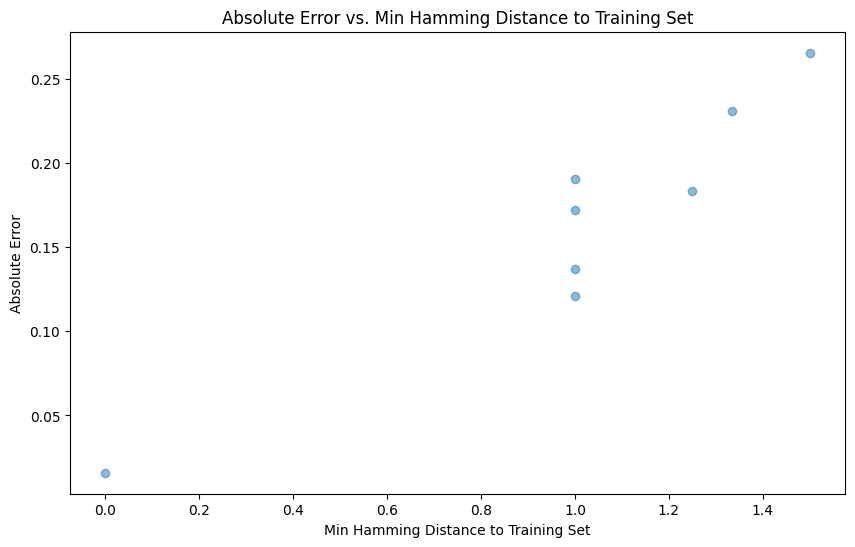

In [17]:
import matplotlib.pyplot as plt

surrogate_score = df.groupby('iteration')['surrogate_score'].mean()
oracle_score = df.groupby('iteration')['oracle_score'].mean()
absolute_error = (surrogate_score - oracle_score).abs()

hamming_distance_per_iteration = df.groupby('iteration')['min_hamming_distance'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(hamming_distance_per_iteration, absolute_error, alpha=0.5)
ax.set_xlabel('Min Hamming Distance to Training Set')
ax.set_ylabel('Absolute Error')
ax.set_title('Absolute Error vs. Min Hamming Distance to Training Set')
plt.show()

## Naive Approach on GB1 Data


In [2]:
experiment_runner = ExperimentRunner(keyword = 'smw_gb1')
experiment_runner.run_and_save()


############################################################
Running experiment: smw_gb1
Method: smw
Dataset: gb1
Runs: 10
Iterations per run: 20
Parallel: True
############################################################

Using 10 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL


Run 1/10 - SMW

Run 2/10 - SMW

Run 9/10 - SMW

Run 7/10 - SMW

Run 6/10 - SMW

Run 4/10 - SMW

Run 3/10 - SMW

Run 8/10 - SMW

Run 5/10 - SMW

Run 10/10 - SMW
✓ Run 6: 12 records (1/10)
✓ Run 7: 6 records (2/10)
✓ Run 10: 6 records (3/10)
✓ Run 1: 8 records (4/10)
✓ Run 2: 6 records (5/10)
✓ Run 4: 11 records (6/10)
✓ Run 8: 8 records (7/10)
✓ Run 5: 5 records (8/10)
✓ Run 9: 14 records (9/10)
✓ Run 3: 11 records (10/10)

Results saved to: results/trajectory_smw_gb1.csv
Total records: 87

Summary:
  Runs: 10
  Iterations per run: 16.1
  Avg records per run: 8.7

Oracle scores:
  Min: -0.3456
  Max: 0.3903
  Mean: 0.1006

Hamming distances:
  Min: 0
  Max: 8.0
  Mean: 2.9
Total time: 679.6 seconds (11.3 minutes)


,method,run_id,seed,iteration,sequence,oracle_score,surrogate_score,min_hamming_distance,dataset
0,smw,6,48,0,QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEFTYDD...,0.090746,0.083716,0,gb1
1,smw,6,48,1,QYKLILNGCTLKGETTTEAVDAATAEKVFKQYANDNGVDGEFTYDD...,0.116306,0.091375,1,gb1
2,smw,6,48,1,QYKLILNSKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEFTYDD...,0.109427,0.098834,1,gb1
3,smw,6,48,2,QYKLILNSKTLKGETTTEAVDAATAPKVFKQYANDNGVDGEFTYDD...,0.131233,0.099795,2,gb1
4,smw,6,48,2,QYKLILNSKTLKGETTTEAVTAATAEKVFKQYANDNGVDGEFTYDD...,0.105067,0.123937,2,gb1
...,...,...,...,...,...,...,...,...,...
82,smw,3,45,7,QYKLILNGCTLKGETTTEAVDAATAEKVFKQYANDNGVVGEFTSWD...,0.057458,0.082737,3,gb1
83,smw,3,45,10,QYKLILNGCTWKGETTTEAVDAATAEKVFKQYANDNGVVGEFTSWD...,0.050728,0.082814,4,gb1
84,smw,3,45,12,QYKLILNGCTWKGETTTEAVDAATWEKVFKQYANDNGVVGEFTSWD...,0.114880,0.082984,5,gb1
85,smw,3,45,14,QYKLILNGCTWKGETTTEAVDAATWEKVFKQYANDNGVVGEFTQWD...,0.154759,0.085823,5,gb1


In [3]:
df = pd.read_csv('results/trajectory_smw_gb1.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")

mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)
print("Mean pairwise Hamming distances per iteration:")
print(mean_hamming_distances)

Mean max oracle score: 0.2946 +- 0.0795
Mean median oracle score: 0.1245 +- 0.0877
Mean pairwise Hamming distances per iteration:
iteration
0      3.488889
1      5.000000
2      6.027778
3      6.833333
4      9.500000
5      9.000000
6      8.000000
7      9.333333
8      9.333333
9      8.000000
10    14.000000
11     0.000000
12    12.000000
13    15.000000
14     9.666667
15    10.666667
16    13.666667
17    10.000000
18    16.000000
20    10.100000
dtype: float64


/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_9127/1201751361.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)


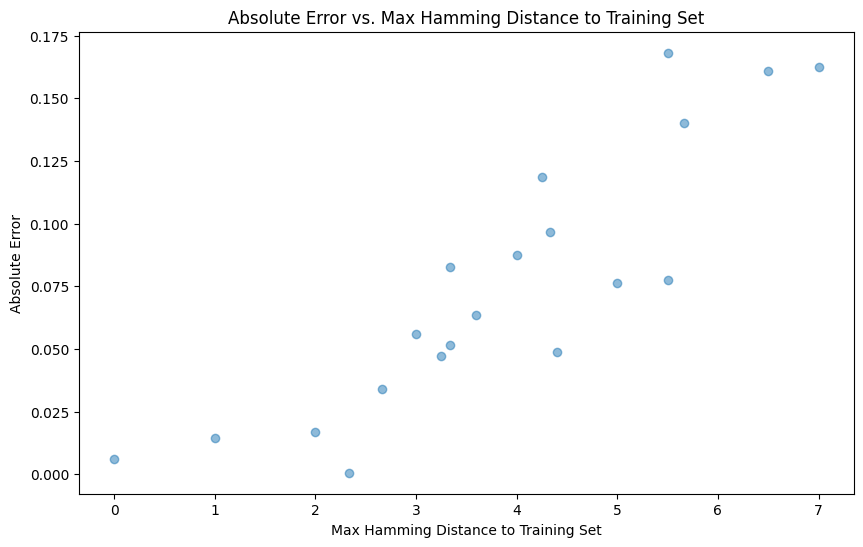

In [ ]:
import matplotlib.pyplot as plt

surrogate_score = df.groupby('iteration')['surrogate_score'].mean()
oracle_score = df.groupby('iteration')['oracle_score'].mean()
absolute_error = (surrogate_score - oracle_score).abs()

hamming_distance_per_iteration = df.groupby('iteration')['min_hamming_distance'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(hamming_distance_per_iteration, absolute_error, alpha=0.5)
ax.set_xlabel('Min Hamming Distance to Training Set')
ax.set_ylabel('Absolute Error')
ax.set_title('Absolute Error vs. Min Hamming Distance to Training Set')
plt.show()

## Reinforcement Appraoch
Scince the naive SMW appraoch is very limited in exploration as the experiments above show, in the following a Reinforcement Learning Approach is used for the same two problems.

In this appraoch the sequences are predicted by a LSTM and scored with a RF. The best 20% of the predicted sequences are then mixed with sequences from the training set and used to retrain the LSTM. 

In [18]:
experiment_runner = ExperimentRunner(keyword='rl_tfbind8')
experiment_runner.run_and_save()


############################################################
Running experiment: rl_tfbind8
Method: rl
Dataset: tfbind8
Runs: 10
Iterations per run: 20
Parallel: True
############################################################

Using 10 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL


Run 7/10 - RL

Run 4/10 - RL

Run 2/10 - RL

Run 1/10 - RL

Run 6/10 - RL

Run 3/10 - RL

Run 5/10 - RL

Run 10/10 - RL

Run 8/10 - RL

Run 9/10 - RL
Pretraining epoch 0/100, Loss: 1.2179
Pretraining epoch 0/100, Loss: 1.2217
Pretraining epoch 0/100, Loss: 1.2242
Pretraining epoch 0/100, Loss: 1.2228
Pretraining epoch 0/100, Loss: 1.2321
Pretraining epoch 0/100, Loss: 1.2305
Pretraining epoch 5/100, Loss: 1.1457
Pretraining epoch 0/100, Loss: 1.2247
Pretraining epoch 0/100, Loss: 1.2232
Pretraining epoch 0/100, Loss: 1.2181
Pretraining epoch 0/100, Loss: 1.2289
Pretraining epoch 5/100, Loss: 1.1599
Pretraining epoch 5/100, Loss: 1.1514
Pretraining epoch 5/100, Loss: 1.1423
Pretraining epoch 10/100, Loss: 1.0717
Pretraining epoch 5/100, Loss: 1.1504
Pretraining epoch 5/100, Loss: 1.1383
Pretraining epoch 5/100, Loss: 1.1453
Pretraining epoch 5/100, Loss: 1.1400
Pretraining epoch 5/100, Loss: 1.1559
Pretraining epoch 5/100, Loss: 1.1505
Pretraining epoch 10/100, Loss: 1.1164
Pretraining

,method,run_id,seed,iteration,sequence,oracle_score,surrogate_score,min_hamming_distance,dataset
0,rl,7,49,0,GAAAATAA,0.573816,0.403682,1,tfbind8
1,rl,7,49,0,AAAGATTA,0.651270,0.392360,2,tfbind8
2,rl,7,49,0,TTAAATTA,0.466087,0.395187,2,tfbind8
3,rl,7,49,0,CTAAATTT,0.502629,0.379399,2,tfbind8
4,rl,7,49,0,TGTAAAAA,0.464808,0.397663,1,tfbind8
...,...,...,...,...,...,...,...,...,...
697,rl,3,45,15,AAAAAAAA,0.524750,0.386010,1,tfbind8
698,rl,3,45,16,AAAAAAAA,0.524750,0.386010,1,tfbind8
699,rl,3,45,17,AAAAAAAA,0.524750,0.386010,1,tfbind8
700,rl,3,45,18,AAAAAAAA,0.524750,0.386010,1,tfbind8


In [19]:
df = pd.read_csv('results/trajectory_rl_tfbind8.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")

mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)
print("Mean pairwise Hamming distances per iteration:")
print(mean_hamming_distances)

Mean max oracle score: 0.8540 +- 0.0314
Mean median oracle score: 0.5737 +- 0.0290
Mean pairwise Hamming distances per iteration:
iteration
0     4.121212
1     3.517505
2     3.504960
3     3.392231
4     3.269565
5     3.317073
6     3.187692
7     3.026667
8     3.185771
9     3.047619
10    3.263158
11    3.463203
12    3.379085
13    3.421053
14    3.385965
15    3.426901
16    3.342105
17    2.780952
18    2.692308
19    2.637363
dtype: float64


/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_9127/77151665.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_hamming_distances = df.groupby('iteration').apply(compute_metrics.mean_pairwise_hamming_distance)


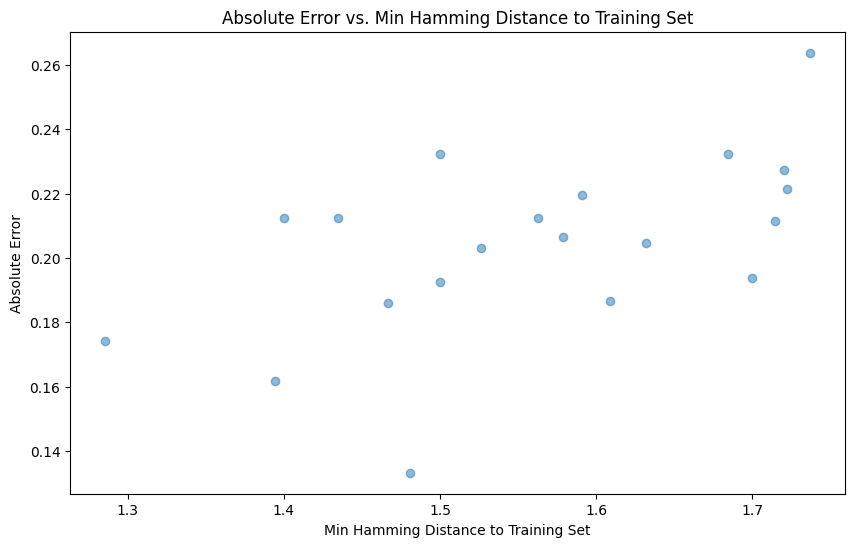

In [20]:
import matplotlib.pyplot as plt

surrogate_score = df.groupby('iteration')['surrogate_score'].mean()
oracle_score = df.groupby('iteration')['oracle_score'].mean()
absolute_error = (surrogate_score - oracle_score).abs()

hamming_distance_per_iteration = df.groupby('iteration')['min_hamming_distance'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(hamming_distance_per_iteration, absolute_error, alpha=0.5)
ax.set_xlabel('Min Hamming Distance to Training Set')
ax.set_ylabel('Absolute Error')
ax.set_title('Absolute Error vs. Min Hamming Distance to Training Set')
plt.show()